# UTS Model Deployment – No. 1 Exploratory Data Analysis & Modeling

**Nama:** Jeremy Anthony Gunawan
**NIM:** 2802500902  
**Dataset:** Dataset B  
**Video Presentasi:** [Tempel link video di sini nanti]

## Tujuan
Notebook ini berisi proses exploratory data analysis (EDA), penanganan missing values, feature engineering, pembagian data train-test, serta pemodelan untuk dua target:
1. **Placement Outcome** untuk tugas klasifikasi
2. **Salary** untuk tugas regresi

Dataset B digunakan karena fitur dan target berada dalam satu file. Analisis dilakukan secara bertahap untuk memahami struktur data, kualitas data, dan memilih pendekatan model yang sesuai.

In [13]:
# import library

import pandas as pd
import numpy as np


In [14]:
df = pd.read_csv("B.csv")
df.head()

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


In [15]:
print("Shape dataset:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())

Shape dataset: (5000, 18)

Nama kolom:
['student_id', 'gender', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa', 'entrance_exam_score', 'technical_skill_score', 'soft_skill_score', 'internship_count', 'live_projects', 'work_experience_months', 'certifications', 'attendance_percentage', 'backlogs', 'extracurricular_activities', 'placement_status', 'salary_package_lpa']


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

In [17]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
gender,5000,2,Male,2504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ssc_percentage,5000.0,NaN,NaN,NaN,72.4258,13.199642,50.0,61.0,72.0,84.0,95.0
hsc_percentage,5000.0,NaN,NaN,NaN,71.9108,12.842781,50.0,61.0,72.0,83.0,94.0
degree_percentage,5000.0,NaN,NaN,NaN,71.8452,10.013196,55.0,63.0,72.0,80.0,89.0
cgpa,5000.0,NaN,NaN,NaN,7.678326,1.237084,5.5,6.6175,7.7,8.75,9.8
entrance_exam_score,5000.0,NaN,NaN,NaN,69.1978,17.325528,40.0,54.0,69.0,84.0,99.0
technical_skill_score,5000.0,NaN,NaN,NaN,69.651,17.179704,40.0,55.0,70.0,84.0,99.0
soft_skill_score,5000.0,NaN,NaN,NaN,69.8396,17.170732,40.0,55.0,69.0,85.0,99.0
internship_count,5000.0,NaN,NaN,NaN,1.9878,1.410975,0.0,1.0,2.0,3.0,4.0


In [18]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().sum() / len(df)) * 100
}).sort_values(by="missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
student_id,0,0.0
gender,0,0.0
ssc_percentage,0,0.0
hsc_percentage,0,0.0
degree_percentage,0,0.0
cgpa,0,0.0
entrance_exam_score,0,0.0
technical_skill_score,0,0.0
soft_skill_score,0,0.0
internship_count,0,0.0


## Initial Data Inspection

Dataset berhasil dimuat dengan ukuran **5.000 baris dan 18 kolom**. Struktur ini sesuai dengan ketentuan **Dataset B**, yaitu fitur dan target berada dalam satu file. Dari hasil inspeksi tipe data, dataset terdiri dari **16 fitur** dan **2 target**, dengan komposisi **14 kolom integer, 2 kolom float, dan 2 kolom kategorikal** (`gender` dan `extracurricular_activities`).

Dua target yang akan dianalisis adalah:
- `placement_status` untuk **klasifikasi**
- `salary_package_lpa` untuk **regresi**

Hasil pengecekan missing values menunjukkan bahwa **tidak terdapat missing values pada seluruh kolom**, sehingga data tergolong bersih dan tidak memerlukan imputasi. Dengan demikian, tahap preprocessing selanjutnya dapat difokuskan pada **encoding fitur kategorikal, analisis distribusi data, korelasi, feature engineering, dan pemilihan fitur**.

Selain itu, kolom `student_id` terindikasi hanya sebagai **identifier**, sehingga kemungkinan tidak memiliki kontribusi prediktif terhadap model. Sementara itu, `salary_package_lpa` menunjukkan banyak nilai **0**, yang mengindikasikan distribusi target regresi berpotensi tidak seimbang dan perlu dianalisis lebih lanjut pada tahap EDA.

## Exploratory Data Analysis – Target Variables

Pada tahap ini dilakukan analisis awal terhadap dua variabel target, yaitu `placement_status` untuk klasifikasi dan `salary_package_lpa` untuk regresi. Tujuan analisis ini adalah untuk memahami distribusi target, mendeteksi potensi ketidakseimbangan kelas, serta melihat karakteristik awal target regresi sebelum masuk ke tahap preprocessing dan modeling.

In [19]:
# Cek distribusi target klasifikasi

placement_counts = df["placement_status"].value_counts().sort_index()
placement_percent = df["placement_status"].value_counts(normalize=True).sort_index() * 100

print("Placement Status Count:")
print(placement_counts)
print("\nPlacement Status Percentage:")
print(placement_percent.round(2))

Placement Status Count:
placement_status
0    4134
1     866
Name: count, dtype: int64

Placement Status Percentage:
placement_status
0    82.68
1    17.32
Name: proportion, dtype: float64


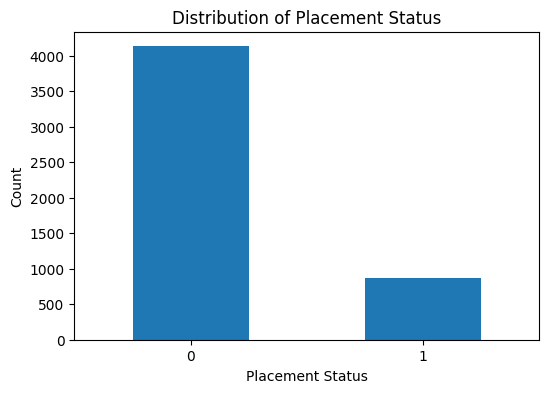

In [20]:
# Visualisasi target klasifikasi

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["placement_status"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [21]:
# Cek distribusi target regresi

print("Salary Package Summary:")
display(df["salary_package_lpa"].describe())

print("\nJumlah salary = 0:")
print((df["salary_package_lpa"] == 0).sum())

print("\nPersentase salary = 0:")
print(round((df["salary_package_lpa"] == 0).mean() * 100, 2), "%")

Salary Package Summary:


count    5000.00000
mean        1.59589
std         3.77582
min         0.00000
25%         0.00000
50%         0.00000
75%         0.00000
max        14.99000
Name: salary_package_lpa, dtype: float64


Jumlah salary = 0:
4134

Persentase salary = 0:
82.68 %


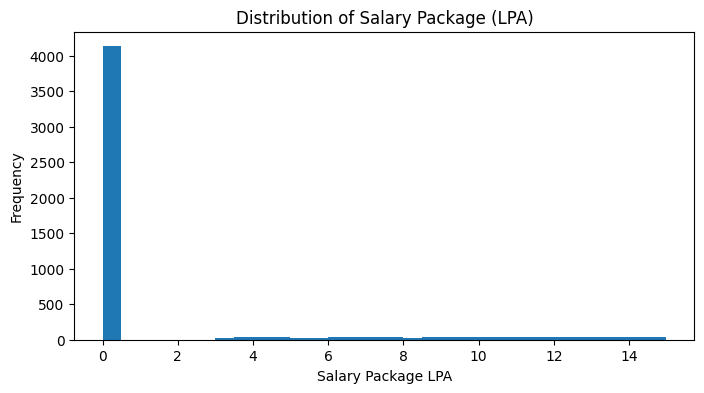

In [22]:
# Visualisasi histogram salary

plt.figure(figsize=(8,4))
df["salary_package_lpa"].plot(kind="hist", bins=30)
plt.title("Distribution of Salary Package (LPA)")
plt.xlabel("Salary Package LPA")
plt.ylabel("Frequency")
plt.show()

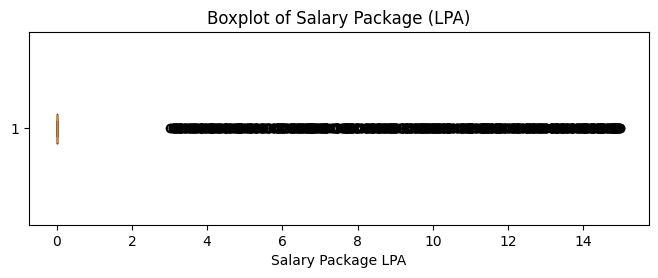

In [23]:
# boxplot salary

plt.figure(figsize=(8,2.5))
plt.boxplot(df["salary_package_lpa"], vert=False)
plt.title("Boxplot of Salary Package (LPA)")
plt.xlabel("Salary Package LPA")
plt.show()

## Insight on Target Variables

Analisis terhadap `placement_status` menunjukkan bahwa target klasifikasi memiliki distribusi yang **tidak seimbang**. Dari total 5.000 data, kelas **0 berjumlah 4.134 data (82,68%)**, sedangkan kelas **1 berjumlah 866 data (17,32%)**. Hal ini menunjukkan adanya **class imbalance**, sehingga pada tahap modeling klasifikasi nanti akurasi saja tidak cukup dan perlu didukung oleh metrik lain seperti **precision, recall, dan F1-score**.

Untuk target regresi `salary_package_lpa`, hasil analisis menunjukkan distribusi yang **sangat tidak normal** dan cenderung **right-skewed**. Sebanyak **4.134 data (82,68%)** memiliki nilai salary **0**, dengan nilai median (**50%**) juga **0.00**. Ini menunjukkan bahwa sebagian besar mahasiswa tidak memiliki salary package, sementara hanya sebagian kecil data memiliki nilai salary positif hingga maksimum **14.99 LPA**.

Histogram dan boxplot memperkuat bahwa target regresi didominasi oleh nilai nol dan memiliki sebaran yang sangat timpang. Kondisi ini penting karena dapat membuat model regresi lebih sulit menangkap pola pada data non-zero. Oleh karena itu, pada tahap modeling regresi nanti perlu digunakan evaluasi yang tepat seperti **MAE, RMSE, dan R²**, serta interpretasi hasil harus dilakukan dengan hati-hati karena distribusi target sangat berat ke nol.

## Exploratory Data Analysis – Relationship Between Targets and Categorical Features

Pada tahap ini dilakukan analisis hubungan antara target klasifikasi dan target regresi, serta eksplorasi fitur kategorikal utama. Analisis ini bertujuan untuk melihat apakah terdapat pola yang kuat antara status placement dan salary, serta memahami distribusi fitur kategorikal yang akan diproses lebih lanjut pada tahap preprocessing.

In [24]:
# Cek hubungan placement_status vs salary_package_lpa

pd.crosstab(
    df["placement_status"],
    df["salary_package_lpa"] == 0,
    margins=True
)

salary_package_lpa,False,True,All
placement_status,,,
0,0,4134,4134
1,866,0,866
All,866,4134,5000


In [25]:
# Cek rata-rata salary berdasarkan placement_status

df.groupby("placement_status")["salary_package_lpa"].describe()

,count,mean,std,min,25%,50%,75%,max
placement_status,,,,,,,,
0,4134.0,0.000000,0.000000,0.00,0.0000,0.000,0.00,0.00
1,866.0,9.214145,3.480803,3.01,6.2925,9.365,12.19,14.99


<Figure size 600x400 with 0 Axes>

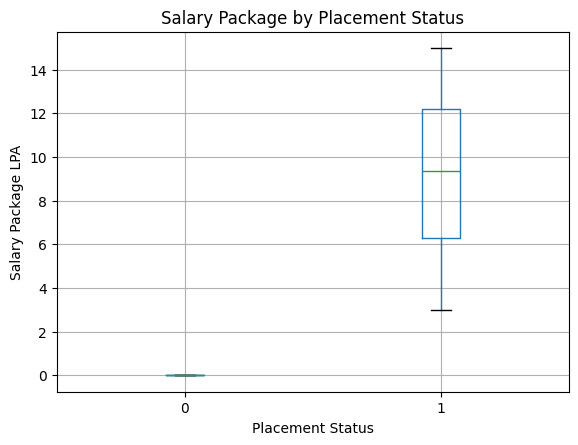

In [26]:
# Visualisasi salary berdasarkan placement_status

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df.boxplot(column="salary_package_lpa", by="placement_status")
plt.title("Salary Package by Placement Status")
plt.suptitle("")
plt.xlabel("Placement Status")
plt.ylabel("Salary Package LPA")
plt.show()

In [27]:
# Cek distribusi gender

print("Gender Count:")
print(df["gender"].value_counts())

print("\nGender Percentage:")
print((df["gender"].value_counts(normalize=True) * 100).round(2))

Gender Count:
gender
Male      2504
Female    2496
Name: count, dtype: int64

Gender Percentage:
gender
Male      50.08
Female    49.92
Name: proportion, dtype: float64


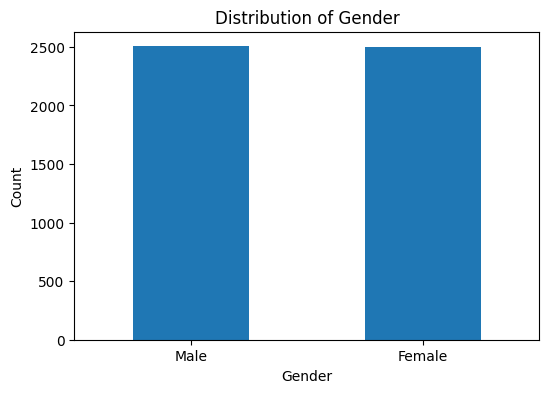

In [28]:
# Visualisasi gender

plt.figure(figsize=(6,4))
df["gender"].value_counts().plot(kind="bar")
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [29]:
# Cek distribusi extracurricular_activities

print("Extracurricular Activities Count:")
print(df["extracurricular_activities"].value_counts())

print("\nExtracurricular Activities Percentage:")
print((df["extracurricular_activities"].value_counts(normalize=True) * 100).round(2))

Extracurricular Activities Count:
extracurricular_activities
No     2553
Yes    2447
Name: count, dtype: int64

Extracurricular Activities Percentage:
extracurricular_activities
No     51.06
Yes    48.94
Name: proportion, dtype: float64


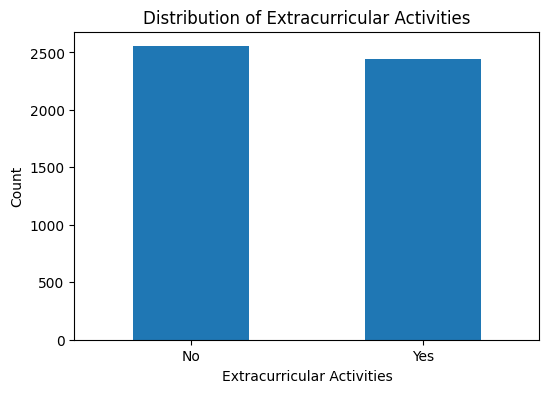

In [30]:
# Visualisasi extracurricular_activities

plt.figure(figsize=(6,4))
df["extracurricular_activities"].value_counts().plot(kind="bar")
plt.title("Distribution of Extracurricular Activities")
plt.xlabel("Extracurricular Activities")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Insight on Relationship Between Targets and Categorical Features

Hasil analisis menunjukkan adanya hubungan yang **sangat kuat** antara `placement_status` dan `salary_package_lpa`. Seluruh data dengan `placement_status = 0` memiliki `salary_package_lpa = 0`, sedangkan seluruh data dengan `placement_status = 1` memiliki salary positif. Temuan ini menunjukkan bahwa status placement secara langsung menentukan apakah mahasiswa memiliki salary package atau tidak.

Statistik deskriptif salary berdasarkan `placement_status` memperkuat temuan tersebut. Pada kelompok `placement_status = 0`, seluruh nilai salary bernilai **0**. Sebaliknya, pada kelompok `placement_status = 1`, salary memiliki rata-rata sekitar **9.21 LPA**, median **9.37 LPA**, nilai minimum **3.01 LPA**, dan maksimum **14.99 LPA**. Hal ini menunjukkan bahwa target regresi hanya memiliki variasi pada mahasiswa yang berhasil placement.

Untuk fitur kategorikal, distribusi `gender` relatif seimbang, dengan **Male 50.08%** dan **Female 49.92%**. Distribusi `extracurricular_activities` juga seimbang, dengan **No 51.06%** dan **Yes 48.94%**. Karena kedua fitur kategorikal tidak menunjukkan ketimpangan distribusi yang ekstrem, keduanya layak dipertahankan untuk tahap modeling setelah dilakukan encoding.

Temuan pada tahap ini sangat penting karena menunjukkan bahwa:
1. `placement_status` dan `salary_package_lpa` memiliki keterkaitan yang sangat erat,
2. model regresi perlu diinterpretasikan dengan hati-hati karena salary bernilai nol untuk seluruh mahasiswa yang tidak placement,
3. fitur kategorikal memiliki distribusi yang stabil dan siap diproses lebih lanjut.

## Exploratory Data Analysis – Numerical Features and Correlation

Pada tahap ini dilakukan analisis terhadap fitur-fitur numerik untuk memahami hubungan linear antarvariabel. Analisis korelasi penting untuk mengidentifikasi fitur yang berpotensi paling relevan terhadap target klasifikasi maupun regresi, serta untuk mendeteksi fitur yang kemungkinan kurang informatif seperti identifier.

In [31]:
# Buat list fitur numerik

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols

['student_id',
 'ssc_percentage',
 'hsc_percentage',
 'degree_percentage',
 'cgpa',
 'entrance_exam_score',
 'technical_skill_score',
 'soft_skill_score',
 'internship_count',
 'live_projects',
 'work_experience_months',
 'certifications',
 'attendance_percentage',
 'backlogs',
 'placement_status',
 'salary_package_lpa']

In [32]:
# Korelasi semua fitur numerik

corr_matrix = df[numeric_cols].corr()
corr_matrix

,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
student_id,1.000000,-0.004994,0.001606,-0.001868,0.016297,-0.007966,0.008262,-0.007278,-0.002550,-0.022502,-0.015962,-0.000635,0.006192,-0.021290,0.023910,0.027633
ssc_percentage,-0.004994,1.000000,-0.019349,0.009593,0.011572,-0.016133,-0.017894,-0.012745,-0.022824,0.008257,0.009549,-0.021682,-0.013790,0.006008,-0.000030,-0.002207
hsc_percentage,0.001606,-0.019349,1.000000,-0.012460,-0.012269,-0.010286,0.004797,-0.002642,-0.012104,-0.019474,-0.014230,-0.024707,-0.001179,0.001939,0.017378,0.012632
degree_percentage,-0.001868,0.009593,-0.012460,1.000000,-0.011088,-0.004231,0.000409,0.013315,0.028425,0.012123,0.014027,0.028933,-0.019107,0.009847,-0.012085,-0.009829
cgpa,0.016297,0.011572,-0.012269,-0.011088,1.000000,0.033028,0.007021,0.002592,-0.000408,-0.003965,0.008016,0.009859,-0.018046,-0.015297,0.278728,0.249022
entrance_exam_score,-0.007966,-0.016133,-0.010286,-0.004231,0.033028,1.000000,0.010851,0.008591,-0.028517,-0.002176,0.000362,0.002547,0.007207,-0.007176,0.000937,-0.001009
technical_skill_score,0.008262,-0.017894,0.004797,0.000409,0.007021,0.010851,1.000000,0.004897,0.019498,-0.007163,0.008767,-0.010880,0.016092,0.031844,0.246573,0.223200
soft_skill_score,-0.007278,-0.012745,-0.002642,0.013315,0.002592,0.008591,0.004897,1.000000,-0.002855,-0.018105,0.004155,0.008650,0.013930,-0.000658,0.197685,0.182165
internship_count,-0.002550,-0.022824,-0.012104,0.028425,-0.000408,-0.028517,0.019498,-0.002855,1.000000,0.002661,0.005741,0.023527,-0.013029,-0.014447,0.011075,0.003564
live_projects,-0.022502,0.008257,-0.019474,0.012123,-0.003965,-0.002176,-0.007163,-0.018105,0.002661,1.000000,-0.021916,-0.032601,-0.014494,0.008607,-0.001519,-0.003859


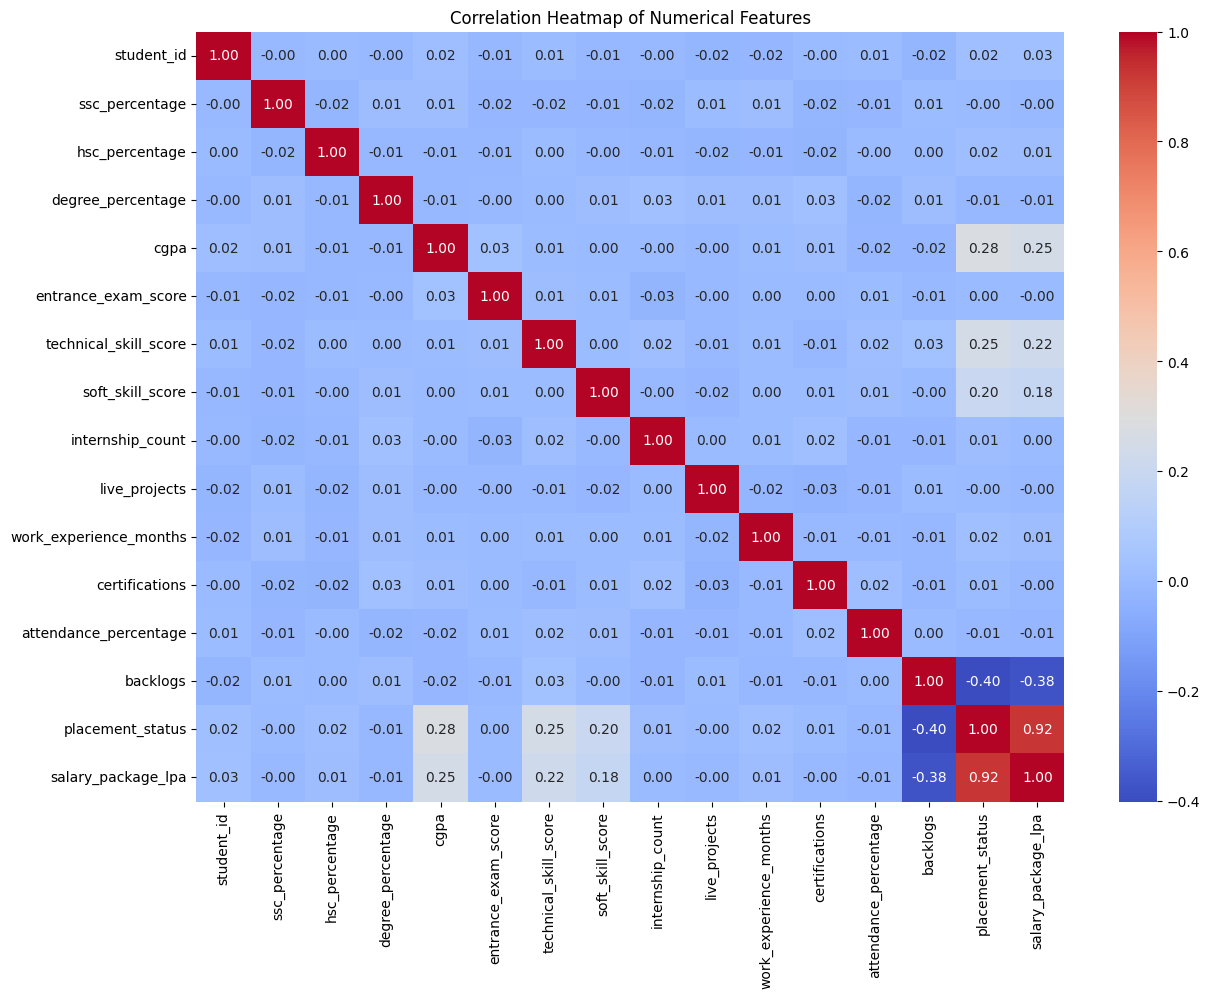

In [33]:
# Heatmap korelasi

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [34]:
# Korelasi terhadap target klasifikasi

placement_corr = corr_matrix["placement_status"].sort_values(ascending=False)
placement_corr

placement_status          1.000000
salary_package_lpa        0.923552
cgpa                      0.278728
technical_skill_score     0.246573
soft_skill_score          0.197685
student_id                0.023910
work_experience_months    0.021453
hsc_percentage            0.017378
internship_count          0.011075
certifications            0.007517
entrance_exam_score       0.000937
ssc_percentage           -0.000030
live_projects            -0.001519
attendance_percentage    -0.012050
degree_percentage        -0.012085
backlogs                 -0.401394
Name: placement_status, dtype: float64

In [35]:
# Korelasi terhadap target regresi

salary_corr = corr_matrix["salary_package_lpa"].sort_values(ascending=False)
salary_corr

salary_package_lpa        1.000000
placement_status          0.923552
cgpa                      0.249022
technical_skill_score     0.223200
soft_skill_score          0.182165
student_id                0.027633
work_experience_months    0.013853
hsc_percentage            0.012632
internship_count          0.003564
entrance_exam_score      -0.001009
ssc_percentage           -0.002207
certifications           -0.003365
live_projects            -0.003859
degree_percentage        -0.009829
attendance_percentage    -0.014698
backlogs                 -0.376909
Name: salary_package_lpa, dtype: float64

In [36]:
# tampilkan top 8 fitur terkuat ke masing-masing target

print("Top 8 features correlated with placement_status:")
display(placement_corr.drop("placement_status").head(8))

print("\nTop 8 features correlated with salary_package_lpa:")
display(salary_corr.drop("salary_package_lpa").head(8))



Top 8 features correlated with placement_status:


salary_package_lpa        0.923552
cgpa                      0.278728
technical_skill_score     0.246573
soft_skill_score          0.197685
student_id                0.023910
work_experience_months    0.021453
hsc_percentage            0.017378
internship_count          0.011075
Name: placement_status, dtype: float64


Top 8 features correlated with salary_package_lpa:


placement_status          0.923552
cgpa                      0.249022
technical_skill_score     0.223200
soft_skill_score          0.182165
student_id                0.027633
work_experience_months    0.013853
hsc_percentage            0.012632
internship_count          0.003564
Name: salary_package_lpa, dtype: float64

## Insight on Numerical Features and Correlation

Analisis korelasi menunjukkan bahwa sebagian besar fitur numerik memiliki hubungan linear yang **lemah** satu sama lain, sehingga tidak terdapat indikasi multikolinearitas yang kuat pada sebagian besar fitur. Namun, terdapat beberapa hubungan yang cukup penting terhadap target.

Untuk target klasifikasi `placement_status`, fitur dengan korelasi positif tertinggi adalah `salary_package_lpa` (**0.9236**), `cgpa` (**0.2787**), `technical_skill_score` (**0.2466**), dan `soft_skill_score` (**0.1977**). Ini menunjukkan bahwa mahasiswa dengan performa akademik yang lebih baik dan kemampuan teknis maupun soft skill yang lebih tinggi cenderung memiliki peluang placement yang lebih besar. Di sisi lain, `backlogs` memiliki korelasi negatif paling kuat terhadap `placement_status` (**-0.4014**), yang menunjukkan bahwa semakin banyak backlog, semakin kecil kemungkinan mahasiswa mendapatkan placement.

Untuk target regresi `salary_package_lpa`, pola korelasi juga serupa. Fitur dengan korelasi positif tertinggi adalah `placement_status` (**0.9236**), `cgpa` (**0.2490**), `technical_skill_score` (**0.2232**), dan `soft_skill_score` (**0.1822**). Sementara itu, `backlogs` kembali menunjukkan korelasi negatif yang cukup kuat (**-0.3769**), sehingga backlog menjadi faktor yang berpotensi menurunkan estimasi salary package.

Temuan penting lainnya adalah `student_id` memiliki korelasi yang sangat kecil terhadap kedua target, sehingga kolom ini terindikasi hanya sebagai identifier dan kemungkinan tidak relevan untuk digunakan dalam modeling. Secara keseluruhan, hasil korelasi menunjukkan bahwa fitur yang paling menjanjikan untuk kedua task adalah `cgpa`, `technical_skill_score`, `soft_skill_score`, dan `backlogs`, sedangkan fitur lain cenderung memiliki pengaruh linear yang relatif kecil.

## Feature Selection and Leakage Prevention

Pada tahap ini dilakukan pemilihan fitur untuk masing-masing task, yaitu klasifikasi dan regresi. Langkah ini penting untuk menghindari data leakage, terutama karena dua target dalam dataset memiliki hubungan yang sangat kuat. Selain itu, kolom identifier juga perlu dikeluarkan karena tidak memiliki makna prediktif.

In [37]:
# Buang student_id

df_model = df.drop(columns=["student_id"])
df_model.head()

,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


In [ ]:
# Siapkan dataset untuk klasifikasi
# target = placement_status
# tidak pakai salary_package_lpa sebagai fitur karena akan bocor

X_class = df_model.drop(columns=["placement_status", "salary_package_lpa"])
y_class = df_model["placement_status"]

print("X_class shape:", X_class.shape)
print("y_class shape:", y_class.shape)
print("\nKolom fitur klasifikasi:")
print(X_class.columns.tolist())

X_class shape: (5000, 15)
y_class shape: (5000,)

Kolom fitur klasifikasi:
['gender', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa', 'entrance_exam_score', 'technical_skill_score', 'soft_skill_score', 'internship_count', 'live_projects', 'work_experience_months', 'certifications', 'attendance_percentage', 'backlogs', 'extracurricular_activities']


In [39]:
# Siapkan dataset untuk regresi
# target = salary_package_lpa
# tidak pakai placement_statusKarena dari EDA sudah terbukti hubungan mereka sangat kuat.
# Kalau dipakai, model regresi jadi tidak fair dan bocor.

X_reg = df_model.drop(columns=["salary_package_lpa", "placement_status"])
y_reg = df_model["salary_package_lpa"]

print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)
print("\nKolom fitur regresi:")
print(X_reg.columns.tolist())

X_reg shape: (5000, 15)
y_reg shape: (5000,)

Kolom fitur regresi:
['gender', 'ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa', 'entrance_exam_score', 'technical_skill_score', 'soft_skill_score', 'internship_count', 'live_projects', 'work_experience_months', 'certifications', 'attendance_percentage', 'backlogs', 'extracurricular_activities']


In [40]:
# Identifikasi fitur numerik dan kategorikal untuk klasifikasi

num_features_class = X_class.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features_class = X_class.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features for classification:")
print(num_features_class)

print("\nCategorical features for classification:")
print(cat_features_class)

Numerical features for classification:
['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa', 'entrance_exam_score', 'technical_skill_score', 'soft_skill_score', 'internship_count', 'live_projects', 'work_experience_months', 'certifications', 'attendance_percentage', 'backlogs']

Categorical features for classification:
['gender', 'extracurricular_activities']


In [41]:
# Identifikasi fitur numerik dan kategorikal untuk regresi

num_features_reg = X_reg.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features_reg = X_reg.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features for regression:")
print(num_features_reg)

print("\nCategorical features for regression:")
print(cat_features_reg)

Numerical features for regression:
['ssc_percentage', 'hsc_percentage', 'degree_percentage', 'cgpa', 'entrance_exam_score', 'technical_skill_score', 'soft_skill_score', 'internship_count', 'live_projects', 'work_experience_months', 'certifications', 'attendance_percentage', 'backlogs']

Categorical features for regression:
['gender', 'extracurricular_activities']


In [42]:
# cek distribusi target lagi setelah pemisahan

print("Classification target distribution:")
print(y_class.value_counts())

print("\nRegression target summary:")
print(y_reg.describe())

Classification target distribution:
placement_status
0    4134
1     866
Name: count, dtype: int64

Regression target summary:
count    5000.00000
mean        1.59589
std         3.77582
min         0.00000
25%         0.00000
50%         0.00000
75%         0.00000
max        14.99000
Name: salary_package_lpa, dtype: float64


## Feature Selection and Leakage Prevention

Pada tahap ini dilakukan pemilihan fitur untuk masing-masing task sekaligus pencegahan data leakage. Kolom `student_id` dikeluarkan dari dataset karena hanya berfungsi sebagai identifier dan tidak memiliki makna prediktif. Setelah kolom tersebut dihapus, tersisa fitur-fitur yang lebih relevan untuk pemodelan.

Untuk task klasifikasi, target yang digunakan adalah `placement_status`, sedangkan `salary_package_lpa` dikeluarkan dari fitur. Keputusan ini penting karena dari hasil EDA sebelumnya diketahui bahwa `salary_package_lpa` memiliki hubungan yang sangat kuat dengan `placement_status`, sehingga jika digunakan sebagai fitur akan menyebabkan kebocoran informasi dan menghasilkan model yang tidak valid.

Untuk task regresi, target yang digunakan adalah `salary_package_lpa`, sedangkan `placement_status` juga dikeluarkan dari fitur. Langkah ini dilakukan untuk alasan yang sama, yaitu menghindari leakage akibat hubungan yang sangat kuat antara kedua target. Dengan demikian, model regresi akan belajar dari fitur-fitur mahasiswa, bukan dari target lain yang secara langsung mencerminkan hasil placement.

Hasil pemisahan menunjukkan bahwa baik task klasifikasi maupun regresi menggunakan **15 fitur input** dengan komposisi:
- **13 fitur numerik**
- **2 fitur kategorikal**, yaitu `gender` dan `extracurricular_activities`

Pendekatan ini menunjukkan bahwa proses feature selection dilakukan secara hati-hati dan sesuai prinsip machine learning yang benar, sehingga dataset siap dilanjutkan ke tahap train-test split dan preprocessing pipeline.

## Train-Test Split

Pada tahap ini dataset dibagi menjadi data training dan data testing dengan rasio 80:20. Pembagian ini dilakukan terpisah untuk task klasifikasi dan regresi agar performa model dapat dievaluasi pada data yang belum pernah dilihat sebelumnya.

In [43]:
# Import train_test_split

from sklearn.model_selection import train_test_split

In [ ]:
# Split data untuk klasifikasi
# Karena target klasifikasi imbalance, pakai stratify=y_class supaya proporsi kelas tetap terjaga.

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Classification Train/Test Shapes:")
print("X_train_class:", X_train_class.shape)
print("X_test_class :", X_test_class.shape)
print("y_train_class:", y_train_class.shape)
print("y_test_class :", y_test_class.shape)

Classification Train/Test Shapes:
X_train_class: (4000, 15)
X_test_class : (1000, 15)
y_train_class: (4000,)
y_test_class : (1000,)


In [45]:
# Cek distribusi target klasifikasi setelah split
print("y_train_class distribution:")
print(y_train_class.value_counts())

print("\ny_test_class distribution:")
print(y_test_class.value_counts())

y_train_class distribution:
placement_status
0    3307
1     693
Name: count, dtype: int64

y_test_class distribution:
placement_status
0    827
1    173
Name: count, dtype: int64


In [46]:
# Split data untuk regresi
# Untuk regresi tidak perlu stratify.

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression Train/Test Shapes:")
print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)
print("y_train_reg:", y_train_reg.shape)
print("y_test_reg :", y_test_reg.shape)

Regression Train/Test Shapes:
X_train_reg: (4000, 15)
X_test_reg : (1000, 15)
y_train_reg: (4000,)
y_test_reg : (1000,)


In [47]:
# Cek ringkasan target regresi setelah split

print("y_train_reg summary:")
print(y_train_reg.describe())

print("\ny_test_reg summary:")
print(y_test_reg.describe())

y_train_reg summary:
count    4000.000000
mean        1.550805
std         3.750887
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.980000
Name: salary_package_lpa, dtype: float64

y_test_reg summary:
count    1000.000000
mean        1.776230
std         3.870608
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.990000
Name: salary_package_lpa, dtype: float64


In [48]:
# cek proporsi zero salary di train dan test

print("Percentage of zero salary in y_train_reg:")
print(round((y_train_reg == 0).mean() * 100, 2), "%")

print("\nPercentage of zero salary in y_test_reg:")
print(round((y_test_reg == 0).mean() * 100, 2), "%")

Percentage of zero salary in y_train_reg:
83.32 %

Percentage of zero salary in y_test_reg:
80.1 %


## Train-Test Split

Pada tahap ini dataset dibagi menjadi data training dan data testing dengan rasio **80:20** untuk masing-masing task. Untuk task klasifikasi, pembagian dilakukan menggunakan parameter **stratify** agar proporsi kelas tetap terjaga mengingat target `placement_status` bersifat tidak seimbang. Hasil split menunjukkan bahwa data klasifikasi terbagi menjadi **4.000 data training** dan **1.000 data testing**, dengan distribusi kelas yang tetap proporsional, yaitu 3.307:693 pada data training dan 827:173 pada data testing.

Untuk task regresi, data juga dibagi menjadi **4.000 data training** dan **1.000 data testing**. Hasil ringkasan target menunjukkan bahwa distribusi `salary_package_lpa` pada data training dan testing tetap memiliki karakteristik yang serupa, dengan median tetap **0** pada kedua subset. Selain itu, proporsi nilai salary = 0 juga masih dominan, yaitu **83.32%** pada data training dan **80.10%** pada data testing.

Hasil ini menunjukkan bahwa proses pembagian data telah dilakukan dengan baik. Data training siap digunakan untuk membangun model, sedangkan data testing akan digunakan untuk mengevaluasi performa model secara objektif pada data yang belum pernah dilihat sebelumnya.

## Preprocessing and Simple Feature Engineering

Pada tahap ini dilakukan preprocessing sebelum modeling, meliputi scaling untuk fitur numerik dan encoding untuk fitur kategorikal. Proses ini penting agar data memiliki format yang sesuai untuk algoritma machine learning, khususnya model yang sensitif terhadap skala fitur. Preprocessing dilakukan menggunakan data training terlebih dahulu untuk menghindari data leakage.

In [49]:
# Import library preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [50]:
# Buat preprocessor untuk klasifikasi

preprocessor_class = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_class),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_class)
    ]
)

preprocessor_class

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [51]:
# Fit-transform train dan transform test untuk klasifikasi

X_train_class_prepared = preprocessor_class.fit_transform(X_train_class)
X_test_class_prepared = preprocessor_class.transform(X_test_class)

print("Prepared classification data shapes:")
print("X_train_class_prepared:", X_train_class_prepared.shape)
print("X_test_class_prepared :", X_test_class_prepared.shape)

Prepared classification data shapes:
X_train_class_prepared: (4000, 17)
X_test_class_prepared : (1000, 17)


In [52]:
# Lihat nama fitur hasil transform klasifikasi

feature_names_class = preprocessor_class.get_feature_names_out()
print("Total transformed features for classification:", len(feature_names_class))
print(feature_names_class)

Total transformed features for classification: 17
['num__ssc_percentage' 'num__hsc_percentage' 'num__degree_percentage'
 'num__cgpa' 'num__entrance_exam_score' 'num__technical_skill_score'
 'num__soft_skill_score' 'num__internship_count' 'num__live_projects'
 'num__work_experience_months' 'num__certifications'
 'num__attendance_percentage' 'num__backlogs' 'cat__gender_Female'
 'cat__gender_Male' 'cat__extracurricular_activities_No'
 'cat__extracurricular_activities_Yes']


In [53]:
# Buat preprocessor untuk regresi

preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_reg)
    ]
)

preprocessor_reg

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [54]:
# Fit-transform train dan transform test untuk regresi

X_train_reg_prepared = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_prepared = preprocessor_reg.transform(X_test_reg)

print("Prepared regression data shapes:")
print("X_train_reg_prepared:", X_train_reg_prepared.shape)
print("X_test_reg_prepared :", X_test_reg_prepared.shape)

Prepared regression data shapes:
X_train_reg_prepared: (4000, 17)
X_test_reg_prepared : (1000, 17)


In [55]:
# Lihat nama fitur hasil transform regresi

feature_names_reg = preprocessor_reg.get_feature_names_out()
print("Total transformed features for regression:", len(feature_names_reg))
print(feature_names_reg)

Total transformed features for regression: 17
['num__ssc_percentage' 'num__hsc_percentage' 'num__degree_percentage'
 'num__cgpa' 'num__entrance_exam_score' 'num__technical_skill_score'
 'num__soft_skill_score' 'num__internship_count' 'num__live_projects'
 'num__work_experience_months' 'num__certifications'
 'num__attendance_percentage' 'num__backlogs' 'cat__gender_Female'
 'cat__gender_Male' 'cat__extracurricular_activities_No'
 'cat__extracurricular_activities_Yes']


In [56]:
# tampilkan beberapa fitur hasil encoding

print("Categorical features after one-hot encoding (classification/regression should be similar):")
encoded_features = [f for f in feature_names_class if "cat__" in f]
print(encoded_features)

Categorical features after one-hot encoding (classification/regression should be similar):
['cat__gender_Female', 'cat__gender_Male', 'cat__extracurricular_activities_No', 'cat__extracurricular_activities_Yes']


## Preprocessing and Simple Feature Engineering

Pada tahap ini dilakukan preprocessing sebelum modeling dengan menggunakan `ColumnTransformer`. Fitur numerik diproses menggunakan **StandardScaler** agar memiliki skala yang lebih seragam, sedangkan fitur kategorikal diproses menggunakan **OneHotEncoder** agar dapat digunakan oleh algoritma machine learning.

Proses preprocessing dilakukan secara benar dengan skema **fit pada data training** dan **transform pada data testing**, sehingga tidak terjadi data leakage. Untuk task klasifikasi maupun regresi, hasil transform menghasilkan data dengan dimensi:
- **4.000 x 17** untuk data training
- **1.000 x 17** untuk data testing

Jumlah fitur bertambah dari 15 menjadi **17 fitur** karena dua fitur kategorikal diubah menjadi beberapa kolom dummy melalui one-hot encoding. Hasil encoding menunjukkan bahwa fitur kategorikal berubah menjadi:
- `cat__gender_Female`
- `cat__gender_Male`
- `cat__extracurricular_activities_No`
- `cat__extracurricular_activities_Yes`

Sementara itu, fitur numerik tetap dipertahankan dalam bentuk yang telah diskalakan. Dengan demikian, dataset telah berada dalam format yang siap digunakan untuk proses modeling klasifikasi dan regresi.

## Classification Modeling

Pada tahap ini dibangun tiga algoritma klasifikasi untuk memprediksi `placement_status`, yaitu Logistic Regression, Decision Tree, dan Random Forest. Karena target klasifikasi bersifat imbalanced, evaluasi model tidak hanya menggunakan accuracy, tetapi juga precision, recall, dan F1-score agar performa model dapat dianalisis secara lebih lengkap.

In [57]:
# Import library model dan metrik

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

In [58]:
# Buat dictionary model klasifikasi

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [59]:
# Training dan evaluasi semua model klasifikasi

classification_results = []

for model_name, model in classification_models.items():
    model.fit(X_train_class_prepared, y_train_class)
    y_pred = model.predict(X_test_class_prepared)

    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_class, y_pred),
        "Precision": precision_score(y_test_class, y_pred, zero_division=0),
        "Recall": recall_score(y_test_class, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test_class, y_pred, zero_division=0)
    })

classification_results_df = pd.DataFrame(classification_results).sort_values(by="F1-Score", ascending=False)
classification_results_df

,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,1.000,1.000000,1.000000,1.000000
2,Random Forest,1.000,1.000000,1.000000,1.000000
0,Logistic Regression,0.891,0.719178,0.606936,0.658307


In [60]:
# Lihat classification report per model

for model_name, model in classification_models.items():
    y_pred = model.predict(X_test_class_prepared)
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test_class, y_pred, zero_division=0))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       827
           1       0.72      0.61      0.66       173

    accuracy                           0.89      1000
   macro avg       0.82      0.78      0.80      1000
weighted avg       0.89      0.89      0.89      1000


=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       827
           1       1.00      1.00      1.00       173

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       827
           1       1.00      1.00      1.00       173

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000

In [61]:
# tampilkan model terbaik sementara

best_classification_model_name = classification_results_df.iloc[0]["Model"]
print("Best classification model based on F1-Score:", best_classification_model_name)
classification_results_df

Best classification model based on F1-Score: Decision Tree


,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,1.000,1.000000,1.000000,1.000000
2,Random Forest,1.000,1.000000,1.000000,1.000000
0,Logistic Regression,0.891,0.719178,0.606936,0.658307


In [62]:
# simpan model terbaik sementara

best_classification_model = classification_models[best_classification_model_name]
best_classification_model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## Classification Modeling Results

Pada tahap ini dilakukan perbandingan tiga algoritma klasifikasi, yaitu **Logistic Regression**, **Decision Tree**, dan **Random Forest**, untuk memprediksi `placement_status`. Evaluasi dilakukan menggunakan **accuracy, precision, recall, dan F1-score** karena target klasifikasi bersifat tidak seimbang.

Hasil evaluasi menunjukkan bahwa **Decision Tree** dan **Random Forest** memberikan performa sempurna pada data testing, dengan nilai **accuracy, precision, recall, dan F1-score masing-masing sebesar 1.00**. Sementara itu, **Logistic Regression** memberikan performa yang lebih rendah, dengan accuracy sekitar **0.891** dan F1-score sekitar **0.658**.

Pada Logistic Regression, performa kelas minoritas (`placement_status = 1`) masih lebih lemah dibandingkan dua model lainnya, khususnya pada nilai recall yang berada di sekitar **0.61**. Hal ini menunjukkan bahwa Logistic Regression masih kehilangan sebagian data positif. Sebaliknya, Decision Tree dan Random Forest mampu mengklasifikasikan seluruh data testing dengan sangat baik.

Berdasarkan metrik evaluasi, **Decision Tree** dan **Random Forest** menjadi model terbaik untuk task klasifikasi pada dataset ini. Performa yang sangat tinggi mengindikasikan bahwa pola pemisahan kelas pada dataset kemungkinan sangat jelas, sehingga model berbasis tree dapat menangkap hubungan antarfitur dengan sangat efektif. Untuk sementara, model terbaik dipilih berdasarkan **F1-score**, yaitu **Decision Tree**.

## Regression Modeling

Pada tahap ini dibangun tiga algoritma regresi untuk memprediksi `salary_package_lpa`, yaitu Linear Regression, Decision Tree Regressor, dan Random Forest Regressor. Evaluasi model dilakukan menggunakan MAE, RMSE, dan R² agar kualitas prediksi dapat dianalisis dari sisi error maupun kemampuan model dalam menjelaskan variasi target.

In [63]:
# Import library model dan metrik regresi

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [64]:
# Buat dictionary model regresi

regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
}

In [65]:
# Training dan evaluasi semua model regresi

regression_results = []

for model_name, model in regression_models.items():
    model.fit(X_train_reg_prepared, y_train_reg)
    y_pred = model.predict(X_test_reg_prepared)

    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)

    regression_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

regression_results_df = pd.DataFrame(regression_results).sort_values(by="R2", ascending=False)
regression_results_df

,Model,MAE,RMSE,R2
2,Random Forest Regressor,0.597251,1.553334,0.838785
1,Decision Tree Regressor,0.723470,2.047110,0.720000
0,Linear Regression,2.313713,3.231557,0.302250


In [66]:
# Lihat beberapa prediksi contoh per model

for model_name, model in regression_models.items():
    y_pred = model.predict(X_test_reg_prepared)
    comparison_df = pd.DataFrame({
        "Actual": y_test_reg.values[:10],
        "Predicted": y_pred[:10]
    })
    print(f"\n=== {model_name} ===")
    display(comparison_df)


=== Linear Regression ===


,Actual,Predicted
0,0.0,-0.168647
1,0.0,1.027243
2,0.0,4.346077
3,0.0,2.028139
4,0.0,4.474843
5,0.0,-1.289777
6,0.0,2.871679
7,0.0,2.473029
8,0.0,4.995114
9,0.0,3.443750



=== Decision Tree Regressor ===


,Actual,Predicted
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,0.0



=== Random Forest Regressor ===


,Actual,Predicted
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,0.0


In [67]:
# Tampilkan model terbaik sementara

best_regression_model_name = regression_results_df.iloc[0]["Model"]
print("Best regression model based on R2:", best_regression_model_name)
regression_results_df

Best regression model based on R2: Random Forest Regressor


,Model,MAE,RMSE,R2
2,Random Forest Regressor,0.597251,1.553334,0.838785
1,Decision Tree Regressor,0.723470,2.047110,0.720000
0,Linear Regression,2.313713,3.231557,0.302250


In [68]:
# Simpan model terbaik sementara ke variabel

best_regression_model = regression_models[best_regression_model_name]
best_regression_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Regression Modeling Results

Pada tahap ini dilakukan perbandingan tiga algoritma regresi, yaitu **Linear Regression**, **Decision Tree Regressor**, dan **Random Forest Regressor**, untuk memprediksi `salary_package_lpa`. Evaluasi dilakukan menggunakan **MAE**, **RMSE**, dan **R²** agar kualitas model dapat dianalisis dari sisi besarnya error maupun kemampuan model dalam menjelaskan variasi target.

Hasil evaluasi menunjukkan bahwa **Random Forest Regressor** memberikan performa terbaik, dengan nilai **MAE sekitar 0.597**, **RMSE sekitar 1.553**, dan **R² sekitar 0.839**. Di posisi kedua, **Decision Tree Regressor** juga menunjukkan performa yang cukup baik, dengan **R² sekitar 0.720**. Sementara itu, **Linear Regression** memberikan performa paling rendah, dengan **MAE sekitar 2.314**, **RMSE sekitar 3.232**, dan **R² sekitar 0.302**.

Contoh prediksi memperlihatkan bahwa model berbasis tree, khususnya Decision Tree dan Random Forest, mampu menangkap banyak kasus salary = 0 dengan sangat baik. Sebaliknya, Linear Regression menghasilkan beberapa prediksi negatif dan nilai yang cukup jauh dari nilai aktual, yang menunjukkan bahwa model linear kurang sesuai untuk pola distribusi target pada dataset ini.

Berdasarkan hasil perbandingan, **Random Forest Regressor** dipilih sebagai model terbaik sementara untuk task regresi karena memiliki **R² tertinggi** dan error paling rendah. Hal ini menunjukkan bahwa hubungan antara fitur dan `salary_package_lpa` cenderung lebih kompleks dan lebih baik ditangkap oleh model non-linear berbasis ensemble.

## Final Conclusion

Berdasarkan hasil exploratory data analysis, dataset memiliki **5.000 baris dan 18 kolom**, tanpa missing values, sehingga kualitas data tergolong baik untuk proses modeling. Terdapat dua target utama, yaitu `placement_status` untuk klasifikasi dan `salary_package_lpa` untuk regresi. Analisis awal menunjukkan bahwa target klasifikasi bersifat **imbalanced**, sedangkan target regresi sangat **right-skewed** dan didominasi oleh nilai **0**.

Hasil EDA juga menunjukkan bahwa `placement_status` memiliki hubungan yang sangat kuat dengan `salary_package_lpa`, sehingga kedua target harus dipisahkan secara hati-hati untuk menghindari **data leakage**. Oleh karena itu, `student_id` dihapus karena hanya berfungsi sebagai identifier, `salary_package_lpa` tidak digunakan sebagai fitur pada task klasifikasi, dan `placement_status` tidak digunakan sebagai fitur pada task regresi.

Berdasarkan analisis korelasi, fitur yang paling relevan terhadap kedua target adalah `cgpa`, `technical_skill_score`, `soft_skill_score`, dan `backlogs`. Setelah itu, dilakukan preprocessing menggunakan **StandardScaler** untuk fitur numerik dan **OneHotEncoder** untuk fitur kategorikal, sehingga data siap digunakan dalam proses modeling.

Pada task klasifikasi, tiga model dibandingkan, yaitu **Logistic Regression**, **Decision Tree**, dan **Random Forest**. Hasil evaluasi menunjukkan bahwa **Decision Tree** dan **Random Forest** memberikan performa terbaik dengan metrik sempurna pada data testing, sedangkan Logistic Regression memiliki performa yang lebih rendah, khususnya pada kelas minoritas. Berdasarkan **F1-score**, model terbaik untuk klasifikasi dipilih sebagai **Decision Tree**.

Pada task regresi, tiga model yang dibandingkan adalah **Linear Regression**, **Decision Tree Regressor**, dan **Random Forest Regressor**. Hasil evaluasi menunjukkan bahwa **Random Forest Regressor** memberikan performa terbaik dengan **MAE terendah, RMSE terendah, dan R² tertinggi**, sehingga dipilih sebagai model terbaik untuk task regresi. Linear Regression menjadi model dengan performa terendah, yang menunjukkan bahwa pola target regresi lebih cocok dimodelkan dengan pendekatan non-linear.

Secara keseluruhan, eksperimen pada notebook ini menunjukkan bahwa model berbasis **tree** dan **ensemble** lebih sesuai untuk karakteristik dataset ini dibandingkan model linear. Hasil notebook ini akan menjadi dasar untuk tahap berikutnya, yaitu pembangunan **pipeline scikit-learn**, penyimpanan model terbaik, dan deployment.

In [69]:
# buat tabel ringkasan model terbaik

final_summary = pd.DataFrame({
    "Task": ["Classification", "Regression"],
    "Best Model": [best_classification_model_name, best_regression_model_name],
    "Main Metric": ["F1-Score", "R2"]
})

final_summary

,Task,Best Model,Main Metric
0,Classification,Decision Tree,F1-Score
1,Regression,Random Forest Regressor,R2


In [70]:
# tampilkan metrik model terbaik

best_class_row = classification_results_df.iloc[0]
best_reg_row = regression_results_df.iloc[0]

print("Best Classification Model Summary:")
display(best_class_row)

print("\nBest Regression Model Summary:")
display(best_reg_row)

Best Classification Model Summary:


Model        Decision Tree
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1-Score               1.0
Name: 1, dtype: object


Best Regression Model Summary:


Model    Random Forest Regressor
MAE                     0.597251
RMSE                    1.553334
R2                      0.838785
Name: 2, dtype: object